# Práctica 7: Coeficientes de Fresnel
Universidad Nacional de Colombia. Departamento de Física

Mediciones en Óptica y Acústica

Integrantes:
- Andrés Felipe Pinzón Harker
- Cristian Camilo Pérez Puentes



## Previos

In [80]:
import ipywidgets as wid
import colorcet as cc
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


# plt.style.use("seaborn-v0_8-bright")
mpl.rcParams.update(
    {
        "legend.fontsize": 20,
        "axes.labelsize": 20,
        "axes.titlesize": 24,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "figure.titlesize": 24,
        "axes.titlepad": 10,
        "text.usetex": True,
        "font.family": "Times New Roman",
        "mathtext.fontset": "dejavusans",
        "font.size": 20,
        "axes.labelweight": "bold",
        "axes.grid.which": "both",
        "axes.grid": True,
        "grid.alpha": 0.5
    }
)

colors = cc.glasbey_dark
# Configuracion de colores
k = 0

# Rotar la lista: número positivo para rotar a la derecha, negativo para rotar a la izquierda
colors = colors[-k:] + colors[:-k]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=colors)

Se ubican los datos

In [81]:
directorio_raiz = "data/"
directorios_relativo = ["LuzLaserS/organizados_por_grados/","LuzLinternaS/organizados_por_grados/", "LuzLinternaP/organizados_por_grados/", "LuzLinternaSinPolarizar/organizados_por_grados/"]
directorios = [directorio_raiz + directorios for directorios in directorios_relativo]

## Visualización de datos

### Extracción de datos

In [82]:
# Almacenar los resultados
todos_los_resultados = []

# Procesar cada directorio
for directorio in directorios:
    for file_name in os.listdir(directorio):
        file_path = os.path.join(directorio, file_name)
        
        # Verificar que el archivo sea un CSV
        if file_name.endswith(".csv"):
            df = pd.read_csv(file_path)
            
            # Tomar la segunda columna (iluminancia)
            if df.shape[1] > 1:
                data = df.iloc[:, 1].dropna().values  # Segunda columna con iluminancia
            
                # Calcular la media y la incertidumbre
                mean_illuminance = np.mean(data)
                uncertainty = np.std(data, ddof=1) / np.sqrt(len(data))
            
                # Extraer ángulo desde el nombre del archivo
                angle = ''.join(filter(str.isdigit, file_name))
            
                # Guardar resultados con el nombre del directorio
                todos_los_resultados.append([directorio, float(angle), mean_illuminance, uncertainty])

# Crear un DataFrame con los resultados
results_df = pd.DataFrame(todos_los_resultados, columns=["Directorio", "Ángulo (grados)", "Iluminancia promedio (lx)", "Incertidumbre (lx)"])

# Convertir ángulos a radianes
results_df["Ángulo (radianes)"] = np.radians(results_df["Ángulo (grados)"])



# Excluir el primer directorio y graficarlo aparte
primer_directorio = results_df["Directorio"].unique()[0]
otros_directorios = results_df["Directorio"].unique()[1:]

c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### Reflectancia (no normalizada - radianes)

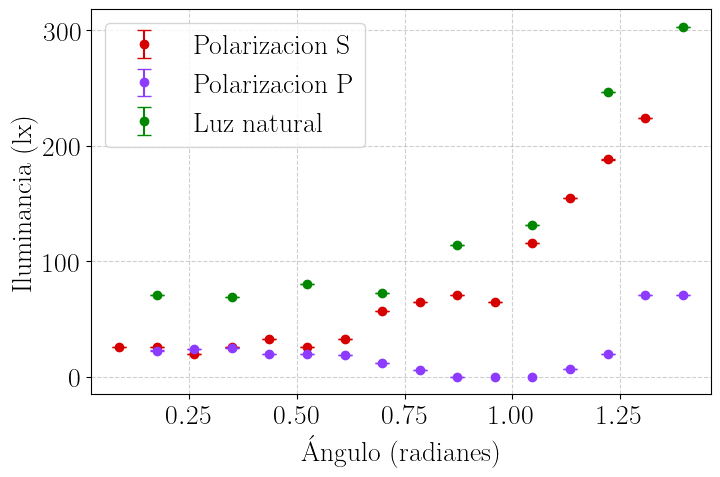

In [ ]:
# Graficar los otros directorios
plt.figure(figsize=(10, 6))
labels = ["Polarizacion S", "Polarizacion P", "Luz natural"]
for i, directorio in enumerate(otros_directorios):
    subset = results_df[results_df["Directorio"] == directorio]
    plt.errorbar(subset["Ángulo (radianes)"], 
                 subset["Iluminancia promedio (lx)"], 
                 yerr=subset["Incertidumbre (lx)"], 
                 fmt='o', capsize=5, label=labels[i])

# Configuración de la gráfica para los otros directorios
plt.xlabel("Ángulo (radianes)")
plt.ylabel("Iluminancia (lx)")
plt.legend()
plt.show()


### Reflectancia (normalizada - radianes)

In [86]:
results_df_original = results_df.copy()

## Ajuste para datos de Luz linterna con polarizacion P

# Identificar datos que son cero para el tercer directorio
tercer_directorio = results_df["Directorio"].unique()[2]
subset_tercer_directorio = results_df[results_df["Directorio"] == tercer_directorio]
subset_tercer_directorio_original = results_df_original[results_df_original["Directorio"] == tercer_directorio]  


# Filtrar filas donde la iluminancia promedio es cero
datos_cero = subset_tercer_directorio[subset_tercer_directorio["Iluminancia promedio (lx)"] == 0]

# Remover filas con iluminancia promedio cero del DataFrame original
results_df = results_df[results_df["Iluminancia promedio (lx)"] != 0]

print("Datos con iluminancia cero para el tercer directorio:")
print(datos_cero)
print(results_df)

# Remover filas con ángulo de 80 grados para el tercer directorio
results_df = results_df[~((results_df["Directorio"] == tercer_directorio) & (results_df["Ángulo (grados)"] == 80))]
subset_tercer_directorio_original = subset_tercer_directorio_original[~(subset_tercer_directorio_original["Ángulo (grados)"] == 80)]

print("Datos después de remover ángulo de 80 grados para el tercer directorio:")
print(results_df)

Datos con iluminancia cero para el tercer directorio:
                                   Directorio  Ángulo (grados)  \
33  data/LuzLinternaP/organizados_por_grados/             50.0   
34  data/LuzLinternaP/organizados_por_grados/             55.0   
35  data/LuzLinternaP/organizados_por_grados/             60.0   

    Iluminancia promedio (lx)  Incertidumbre (lx)  Ángulo (radianes)  
33                        0.0                 0.0           0.872665  
34                        0.0                 NaN           0.959931  
35                        0.0                 NaN           1.047198  
                                           Directorio  Ángulo (grados)  \
0              data/LuzLaserS/organizados_por_grados/             30.0   
1              data/LuzLaserS/organizados_por_grados/             35.0   
2              data/LuzLaserS/organizados_por_grados/             40.0   
3              data/LuzLaserS/organizados_por_grados/             45.0   
4              data/LuzLase

### Polarizaciones (en grados) - DEFINITIVA

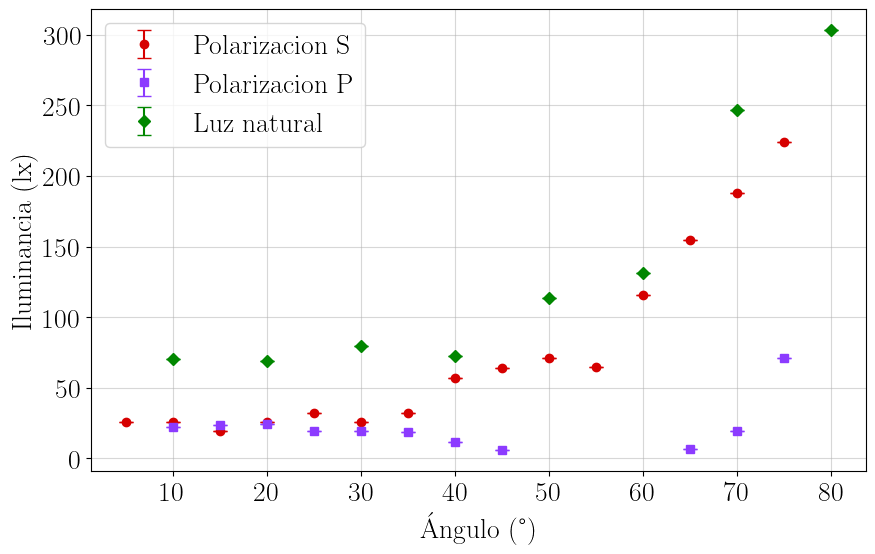

In [88]:
# Graficar los otros directorios
plt.figure(figsize=(10, 6))
labels = ["Polarizacion S", "Polarizacion P", "Luz natural"]
markers = ['o', 's', 'D']  # Different markers for each dataset

for i, directorio in enumerate(otros_directorios):
    subset = results_df[results_df["Directorio"] == directorio]
    plt.errorbar(np.degrees(subset["Ángulo (radianes)"]), 
                 subset["Iluminancia promedio (lx)"], 
                 yerr=subset["Incertidumbre (lx)"], 
                 fmt=markers[i], capsize=5, label=labels[i])

# Configuración de la gráfica para los otros directorios
plt.xlabel("Ángulo (°)")
plt.ylabel("Iluminancia (lx)")
plt.legend()
plt.show()

## 2 y 3. Ángulo de Brewster

Dada la gráfica posterior, podemos ver que a través de la interpolación de grado 3 de las curvas que encontramos el punto más preciso donde la intensidad tiende a cero en la polarización paralela del rayo reflejado. Este ángulo, conocido como *ángulo de Brewster* es donde se cancela la contribución paralela y toda la reflactancia está dada por la polarización perpendicular al plano de incidencia.

Recordemos que se determina según las propiedades del fenómeno como
$$\theta_p = arctan\left( n_t/ n_i \right)$$


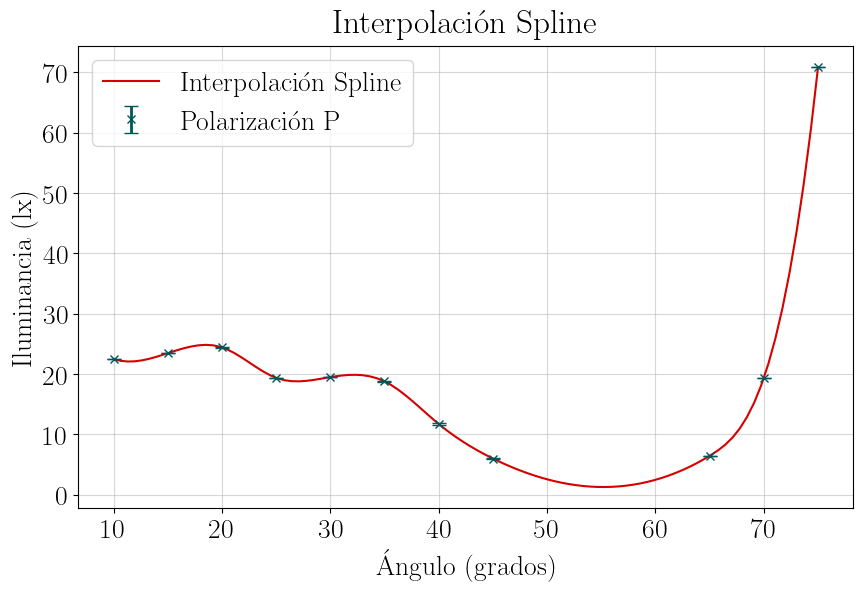

In [108]:
# Interpolacion spline para polarizacion P
subset_polarizacion_p = results_df[results_df["Directorio"] == tercer_directorio]
subset_polarizacion_p = subset_polarizacion_p.sort_values("Ángulo (radianes)").drop_duplicates()
x_p = subset_polarizacion_p["Ángulo (radianes)"].values
y_p = subset_polarizacion_p["Iluminancia promedio (lx)"].values
x_spline = np.linspace(x_p.min(), x_p.max(), 100)
spline_func = make_interp_spline(x_p, y_p, k=3)
y_spline = spline_func(x_spline)

plt.figure(figsize=(10,6))
plt.plot(np.degrees(x_spline), y_spline, '-', label="Interpolación Spline")
plt.errorbar(np.degrees(subset_tercer_directorio_original["Ángulo (radianes)"]), subset_tercer_directorio_original["Iluminancia promedio (lx)"],
             yerr=subset_tercer_directorio_original["Incertidumbre (lx)"],
             fmt='x', capsize=5, elinewidth=2, label="Polarización P", color=colors[8])
plt.xlabel("Ángulo (grados)")
plt.ylabel("Iluminancia (lx)")
plt.title("Interpolación Spline")
plt.legend()
plt.show()

Dado que el medio principal es aire donde $n_i \approx 1$, luego basta escribir
$$n_i \tan \theta_p =  n_t$$

A partir de la gráfica anterir, se verifica que el ángulo es
$$\theta_p = 55.3 \degree$$


In [98]:
min_illuminance_spline = y_spline.min()
min_angle_spline = x_spline[y_spline.argmin()]

print(f"Iluminancia mínima (spline): {min_illuminance_spline:.2f} lx")
min_angle_spline_degrees = np.degrees(min_angle_spline)
print(f"Ángulo correspondiente (spline): {min_angle_spline_degrees:.2f} grados")

Iluminancia mínima (spline): 1.29 lx
Ángulo correspondiente (spline): 55.30 grados


Y ahora basta hallar el indice de refracción con $\theta_p$

In [101]:
result = np.tan(np.radians(min_angle_spline_degrees))
print(f"{result:.2f}")

1.44


Luego, podemos aproximar a partir de la interpolación que el indice de refracción es $n_t = 1.44$

## 4. Polarización resultante

Se utilizó el sensor lineal de luz del aparato celular Nokia G21 descrito en anteriores prácticas. La sensibilidad nominal determinada variaba según la cantidad lumínica suministrada, pero en el menor rango de sensibilidad se apreciaba $\Delta l = 3.2 \, \text{lx}$, no determinada por el fabricante.

### Analizador 70°
Aquí se puede apreciar que en el rango de luminancia, los valores de sensibilidad son altamente apreciables, afectando la medición. A pesar de esto, hay un fenomeno apreciable del cual se puede atribuir a una polarización.

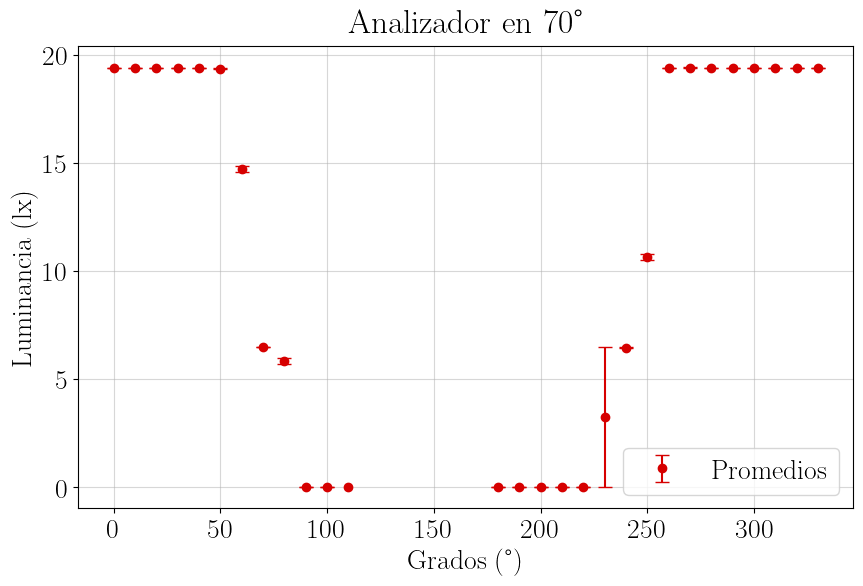

In [122]:
file_path_punto4 = "data/Punto4/luminancia_vs_grados70.csv"
df_punto4 = pd.read_csv(file_path_punto4)
# Renombrar las columnas
df_punto4 = df_punto4.rename(columns={'Grados': 'Grados', 'Luminancia (lx)': 'Luminancia (lx)', 'Incertidumbre (lx)': 'Incertidumbre (lx)'})

# Graficar los datos con barras de error
plt.figure(figsize=(10, 6))
plt.errorbar(df_punto4['Grados'], df_punto4['Luminancia (lx)'], yerr=df_punto4['Incertidumbre (lx)'], fmt='o', capsize=5, label='Promedios')
plt.xlabel('Grados (°)')
plt.ylabel('Luminancia (lx)')
plt.title('Analizador en 70°')
plt.legend()
plt.show()

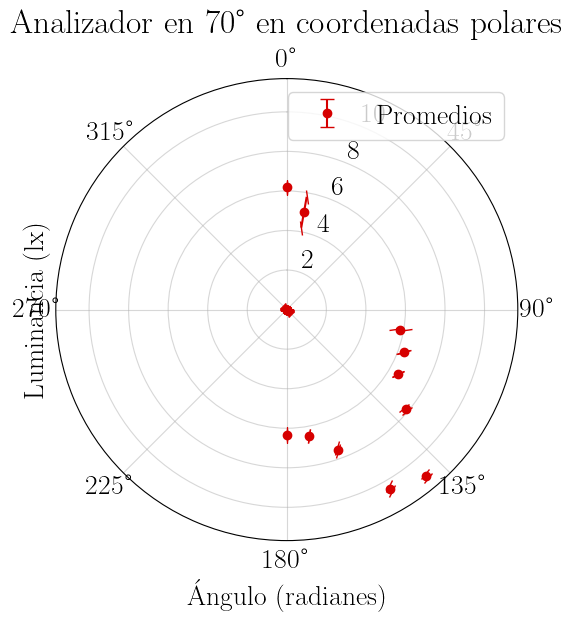

In [121]:
# Graficar los datos en coordenadas polares
plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection='polar')

# Convertir los ángulos a radianes
angles_radians = np.radians(df_punto4['Grados'])

# Graficar los datos con barras de error
ax.errorbar(angles_radians, df_punto4['Luminancia (lx)'], yerr=df_punto4['Incertidumbre (lx)'], fmt='o', capsize=5, label='Promedios')

# Configuración de la gráfica
ax.set_theta_zero_location('N')  # 0 grados en la parte superior
ax.set_theta_direction(-1)  # Sentido de los ángulos en sentido horario
ax.set_xlabel('Ángulo (radianes)')
ax.set_ylabel('Luminancia (lx)')
ax.set_title('Analizador en 70° en coordenadas polares')
ax.legend()
plt.show()


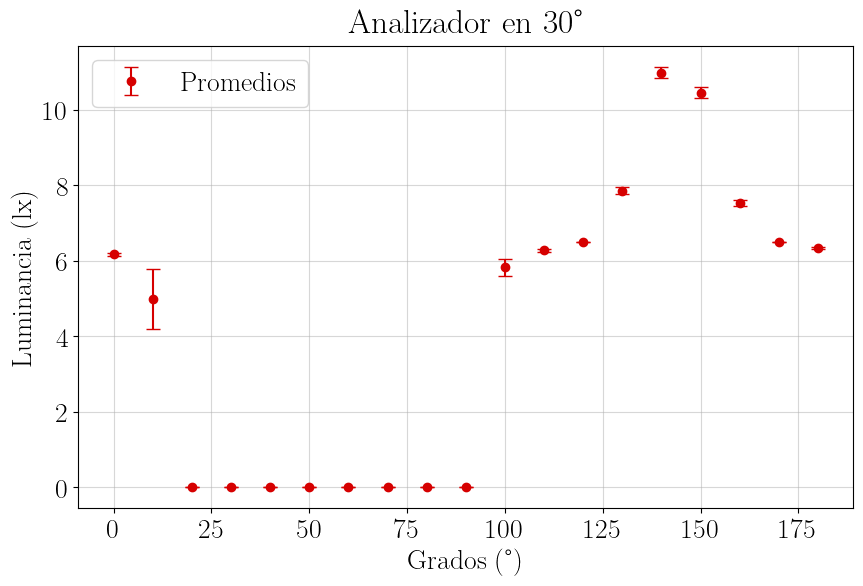

In [120]:
file_path_punto4 = "data/Punto4/luminancia_vs_grados30.csv"
df_punto4 = pd.read_csv(file_path_punto4)
# Renombrar las columnas
df_punto4 = df_punto4.rename(columns={'Grados': 'Grados', 'Luminancia (lx)': 'Luminancia (lx)', 'Incertidumbre (lx)': 'Incertidumbre (lx)'})

# Graficar los datos con barras de error
plt.figure(figsize=(10, 6))
plt.errorbar(df_punto4['Grados'], df_punto4['Luminancia (lx)'], yerr=df_punto4['Incertidumbre (lx)'], fmt='o', capsize=5, label='Promedios')
plt.xlabel('Grados (°)')
plt.ylabel('Luminancia (lx)')
plt.title('Analizador en 30°')
plt.legend()
plt.show()

Se sugiere entonces utilizar una mayor potencia lumínica para mantener rangos donde la sensibilidad no sea un limitante este sensor se mantenga en los rangos de mayor eficiencia. También valdría cambiar el sensor de luminancia a uno calibrado o con rangos de confiabilidad certificado existentes.

Se observa que la sensibilidad del sensor de luz del celular Nokia G21 resulta insuficiente para poder observar los cambios graduales de la intensidad de luz en función del ángulo del polarizador, esto debido a que al pasar la luz por el primer polarizador; para luego ser reflejada; y nuevamente pasando por otro polarizador, dependiendo del ángulo de este ultimo polarizador  decrece considerablemente, causando dificultades en la detección de esta.